## Modelado y simulación de escenarios agroclimáticos

1. Objetivo

En este notebook se desarrolla la fase de modelado del proyecto, siguiendo la metodología CRISP-DM. El objetivo del modelado es identificar patrones y escenarios agroclimáticos mensuales a partir de los índices construidos previamente, mediante técnicas de machine learning no supervisado.

El modelo no busca realizar predicciones determinísticas de variables climáticas futuras, sino simular escenarios representativos de distintos niveles de estrés agroclimático, que sirvan como apoyo a la planificación del cultivo de cacao. Para ello, se emplea el algoritmo K-Means, utilizando como variables de entrada los índices ET, EH, ER, EHR y el índice compuesto IEAM-C.


In [3]:
from google.colab import files
import pandas as pd

# Solicitar al usuario subir el archivo
uploaded = files.upload()

# Obtener el nombre del archivo cargado
file_name = list(uploaded.keys())[0]

# Cargar el archivo CSV
df_mensual = pd.read_csv(file_name)

# Verificar estructura
df_mensual.head()


Saving df_mensual_IEAM_C_cacao.csv to df_mensual_IEAM_C_cacao.csv


,year_month,ET,EH,ER,EHR,IEAM_C,Escenario_IEAM_C
0,2010-01,0.325111,0.935484,0.870968,0.0,0.692695,Crítico
1,2010-02,0.239796,0.607143,0.035714,0.0,0.352296,Favorable
2,2010-03,0.276152,0.612903,0.032258,0.0,0.365104,Favorable
3,2010-04,0.510893,0.633333,0.033333,0.0,0.444935,Favorable
4,2010-05,0.500000,0.516129,0.064516,0.0,0.395161,Favorable


2. Datos de entrada

El conjunto de datos utilizado corresponde a información mensual agregada para el período histórico analizado, e incluye las siguientes variables:

ET: Índice de Estrés Térmico mensual

EH: Índice de Estrés Hídrico mensual

ER: Índice de Estrés por Radiación Solar mensual

EHR: Índice de Estrés por Humedad Relativa mensual

IEAM_C: Índice de Estrés Agroclimático Mensual del Cacao

Escenario_IEAM_C: Clasificación cualitativa del mes (Favorable, Intermedio, Crítico)

Estas variables fueron construidas en cuadernos previos mediante procesos de limpieza, transformación y ingeniería de características, garantizando consistencia temporal y comparabilidad entre meses.

In [4]:
# Variables agroclimáticas seleccionadas para el clustering
variables_modelo = ['ET', 'EH', 'ER', 'EHR', 'IEAM_C']

X = df_mensual[variables_modelo]

X.describe()


,ET,EH,ER,EHR,IEAM_C
count,174.000000,174.000000,174.000000,174.000000,174.000000
mean,0.491159,0.675659,0.256949,0.041533,0.504861
std,0.116921,0.135164,0.279322,0.076793,0.084673
min,0.106797,0.300000,0.000000,0.000000,0.346798
25%,0.421023,0.580645,0.000000,0.000000,0.441198
50%,0.493198,0.677995,0.116240,0.000000,0.496380
75%,0.555236,0.774194,0.466667,0.035119,0.551376
max,0.785714,0.935484,1.000000,0.366667,0.755240


3. Enfoque metodológico de modelado

Dado que el proyecto tiene como alcance apoyar la planificación agrícola y no realizar predicciones exactas de variables climáticas futuras, se opta por un enfoque de aprendizaje no supervisado, específicamente mediante algoritmos de clustering.

Este enfoque permite:

Identificar grupos de meses con comportamientos agroclimáticos similares.

Analizar patrones recurrentes de estrés climático.

Simular escenarios futuros asignando combinaciones de condiciones a los grupos identificados.

El algoritmo seleccionado para este propósito es K-Means, por su interpretabilidad, eficiencia y amplia aceptación en análisis exploratorios y de segmentación.

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


4. Preparación de los datos para el modelo

Previo al entrenamiento del modelo, se realizan las siguientes acciones:

Selección de las variables numéricas relevantes (ET, EH, ER, EHR, IEAM_C).

Normalización o estandarización de las variables, con el fin de evitar que diferencias de escala influyan en la formación de los clústeres.

Validación de la integridad del conjunto de datos (ausencia de valores nulos y consistencia dimensional).

Este paso garantiza que el algoritmo de machine learning aprenda exclusivamente a partir de la estructura interna de los datos y no de etiquetas predefinidas.

In [6]:
df_mensual.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year_month        174 non-null    object 
 1   ET                174 non-null    float64
 2   EH                174 non-null    float64
 3   ER                174 non-null    float64
 4   EHR               174 non-null    float64
 5   IEAM_C            174 non-null    float64
 6   Escenario_IEAM_C  174 non-null    object 
dtypes: float64(5), object(2)
memory usage: 9.6+ KB


5. Entrenamiento del modelo K-Means

El algoritmo K-Means se entrena utilizando el conjunto de datos mensual, definiendo un número de clústeres que representa distintos tipos de escenarios agroclimáticos.

Cada clúster agrupa meses con características similares en términos de:

Nivel de estrés térmico

Condición hídrica

Exposición a radiación solar

Comportamiento de la humedad relativa

Intensidad del índice IEAM-C

El modelo no “predice” valores futuros, sino que aprende patrones históricos y los utiliza como referencia para la simulación de escenarios.

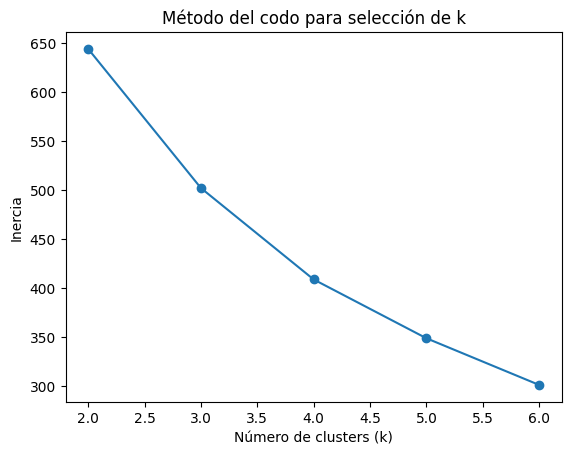

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_values = range(2, 7)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del codo para selección de k')
plt.show()


In [8]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_mensual['Cluster_IEAM'] = clusters


In [9]:
from sklearn.cluster import KMeans

# Entrenamiento del modelo K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df_mensual['Cluster_IEAM'] = kmeans.fit_predict(X_scaled)

# Verificación
df_mensual[['ET', 'EH', 'ER', 'EHR', 'IEAM_C', 'Cluster_IEAM']].head()



,ET,EH,ER,EHR,IEAM_C,Cluster_IEAM
0,0.325111,0.935484,0.870968,0.0,0.692695,0
1,0.239796,0.607143,0.035714,0.0,0.352296,1
2,0.276152,0.612903,0.032258,0.0,0.365104,1
3,0.510893,0.633333,0.033333,0.0,0.444935,2
4,0.500000,0.516129,0.064516,0.0,0.395161,2


6. Simulación de escenarios agroclimáticos futuros

Una vez entrenado el modelo, se construyen escenarios simulados representativos de meses futuros (por ejemplo, junio de 2026), siguiendo este enfoque:

Se generan combinaciones plausibles de valores de ET, EH, ER y EHR, dentro de los rangos observados históricamente.

Se calcula el índice IEAM-C para cada combinación.

El modelo K-Means asigna cada escenario a uno de los clústeres aprendidos.

El escenario se interpreta según las características promedio del clúster asignado.

Este procedimiento permite responder preguntas del tipo:

“Si un mes futuro presenta condiciones similares a ciertos patrones históricos, ¿qué nivel de estrés agroclimático podría esperarse?”

In [10]:
# Estadísticas promedio por cluster
cluster_summary = (
    df_mensual
    .groupby('Cluster_IEAM')[['ET', 'EH', 'ER', 'EHR', 'IEAM_C']]
    .mean()
)

cluster_summary


,ET,EH,ER,EHR,IEAM_C
Cluster_IEAM,,,,,
0,0.519243,0.758913,0.594292,0.030750,0.617680
1,0.387916,0.724452,0.095840,0.084123,0.465752
2,0.567120,0.577300,0.185561,0.009677,0.467517


In [11]:
# Ordenar clusters según nivel de estrés promedio
orden_clusters = (
    df_mensual
    .groupby('Cluster_IEAM')['IEAM_C']
    .mean()
    .sort_values()
)

orden_clusters


,IEAM_C
Cluster_IEAM,
1,0.465752
2,0.467517
0,0.617680


In [12]:
# Crear mapeo automático
cluster_to_scenario = {
    orden_clusters.index[0]: 'Favorable',
    orden_clusters.index[1]: 'Intermedio',
    orden_clusters.index[2]: 'Crítico'
}

df_mensual['Escenario_Simulado'] = df_mensual['Cluster_IEAM'].map(cluster_to_scenario)

# Verificación
df_mensual[['IEAM_C', 'Cluster_IEAM', 'Escenario_Simulado']].head()


,IEAM_C,Cluster_IEAM,Escenario_Simulado
0,0.692695,0,Crítico
1,0.352296,1,Favorable
2,0.365104,1,Favorable
3,0.444935,2,Intermedio
4,0.395161,2,Intermedio


In [13]:
columnas_finales = [
    'year_month',
    'ET',
    'EH',
    'ER',
    'EHR',
    'IEAM_C',
    'Escenario_IEAM_C',
    'Cluster_IEAM',
    'Escenario_Simulado'
]

df_final = df_mensual[columnas_finales]

df_final.head()


,year_month,ET,EH,ER,EHR,IEAM_C,Escenario_IEAM_C,Cluster_IEAM,Escenario_Simulado
0,2010-01,0.325111,0.935484,0.870968,0.0,0.692695,Crítico,0,Crítico
1,2010-02,0.239796,0.607143,0.035714,0.0,0.352296,Favorable,1,Favorable
2,2010-03,0.276152,0.612903,0.032258,0.0,0.365104,Favorable,1,Favorable
3,2010-04,0.510893,0.633333,0.033333,0.0,0.444935,Favorable,2,Intermedio
4,2010-05,0.500000,0.516129,0.064516,0.0,0.395161,Favorable,2,Intermedio


In [14]:
# Convertir year_month a datetime
df_final['year_month'] = pd.to_datetime(df_final['year_month'], format='%Y-%m')


In [15]:
# Extraer el mes (numérico)
df_final['Mes'] = df_final['year_month'].dt.month


In [16]:
# Crear nombre del mes en español manualmente
meses = {
    1: 'Enero',
    2: 'Febrero',
    3: 'Marzo',
    4: 'Abril',
    5: 'Mayo',
    6: 'Junio',
    7: 'Julio',
    8: 'Agosto',
    9: 'Septiembre',
    10: 'Octubre',
    11: 'Noviembre',
    12: 'Diciembre'
}

df_final['Mes_nombre'] = df_final['Mes'].map(meses)

df_final[['year_month', 'Mes', 'Mes_nombre']].head()


,year_month,Mes,Mes_nombre
0,2010-01-01,1,Enero
1,2010-02-01,2,Febrero
2,2010-03-01,3,Marzo
3,2010-04-01,4,Abril
4,2010-05-01,5,Mayo


In [17]:
orden_columnas = [
    'year_month',
    'Mes',
    'Mes_nombre',
    'ET',
    'EH',
    'ER',
    'EHR',
    'IEAM_C',
    'Escenario_IEAM_C',
    'Cluster_IEAM',
    'Escenario_Simulado'
]

df_final = df_final[orden_columnas]

df_final.head()


,year_month,Mes,Mes_nombre,ET,EH,ER,EHR,IEAM_C,Escenario_IEAM_C,Cluster_IEAM,Escenario_Simulado
0,2010-01-01,1,Enero,0.325111,0.935484,0.870968,0.0,0.692695,Crítico,0,Crítico
1,2010-02-01,2,Febrero,0.239796,0.607143,0.035714,0.0,0.352296,Favorable,1,Favorable
2,2010-03-01,3,Marzo,0.276152,0.612903,0.032258,0.0,0.365104,Favorable,1,Favorable
3,2010-04-01,4,Abril,0.510893,0.633333,0.033333,0.0,0.444935,Favorable,2,Intermedio
4,2010-05-01,5,Mayo,0.500000,0.516129,0.064516,0.0,0.395161,Favorable,2,Intermedio


7. Integración con Power BI

Los resultados del modelo, tanto históricos como simulados, pueden ser exportados y visualizados en Power BI, permitiendo:

Visualizar escenarios mensuales por nivel de riesgo.

Comparar meses históricos vs. simulados.

Apoyar la planificación agrícola mediante tableros interactivos orientados a productores y tomadores de decisión.

In [18]:
from google.colab import files

# Nombre del archivo final
nombre_archivo = 'df_final_IEAM_C_escenarios_simulados.csv'

# Exportar a CSV
df_final.to_csv(nombre_archivo, index=False, encoding='utf-8')

# Descargar automáticamente
files.download(nombre_archivo)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
nombre_archivo_excel = 'df_final_IEAM_C_escenarios_simulados.xlsx'

df_final.to_excel(nombre_archivo_excel, index=False)

files.download(nombre_archivo_excel)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

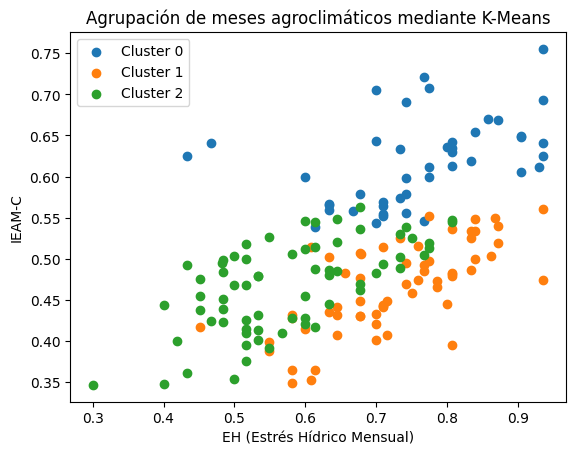

In [22]:
import matplotlib.pyplot as plt

plt.figure()

for c in sorted(df_final['Cluster_IEAM'].unique()):
    subset = df_final[df_final['Cluster_IEAM'] == c]
    plt.scatter(subset['EH'], subset['IEAM_C'], label=f'Cluster {c}')

plt.xlabel("EH (Estrés Hídrico Mensual)")
plt.ylabel("IEAM-C")
plt.title("Agrupación de meses agroclimáticos mediante K-Means")
plt.legend()
plt.show()


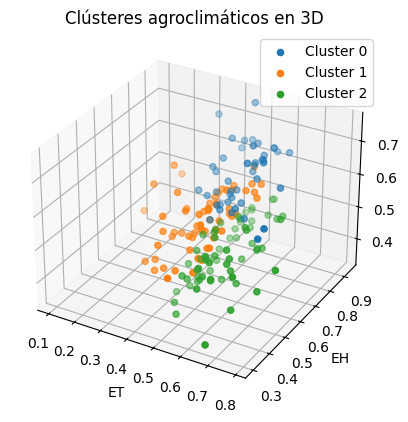

In [23]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for c in sorted(df_final['Cluster_IEAM'].unique()):
    subset = df_final[df_final['Cluster_IEAM'] == c]
    ax.scatter(subset['ET'], subset['EH'], subset['IEAM_C'], label=f'Cluster {c}')

ax.set_xlabel("ET")
ax.set_ylabel("EH")
ax.set_zlabel("IEAM-C")
ax.set_title("Clústeres agroclimáticos en 3D")
ax.legend()
plt.show()


In [24]:
# Inicial del mes (Ej: Enero → E, Abril → A)
df_final['Mes_inicial'] = df_final['Mes_nombre'].str[0]


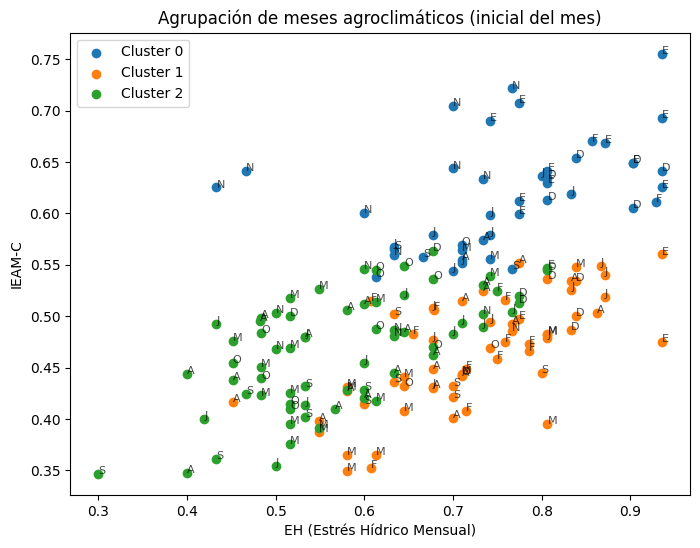

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for c in sorted(df_final['Cluster_IEAM'].unique()):
    subset = df_final[df_final['Cluster_IEAM'] == c]
    plt.scatter(subset['EH'], subset['IEAM_C'], label=f'Cluster {c}')

    # Etiquetas con inicial del mes
    for _, row in subset.iterrows():
        plt.text(
            row['EH'],
            row['IEAM_C'],
            row['Mes_inicial'],
            fontsize=8,
            alpha=0.7
        )

plt.xlabel("EH (Estrés Hídrico Mensual)")
plt.ylabel("IEAM-C")
plt.title("Agrupación de meses agroclimáticos (inicial del mes)")
plt.legend()
plt.show()


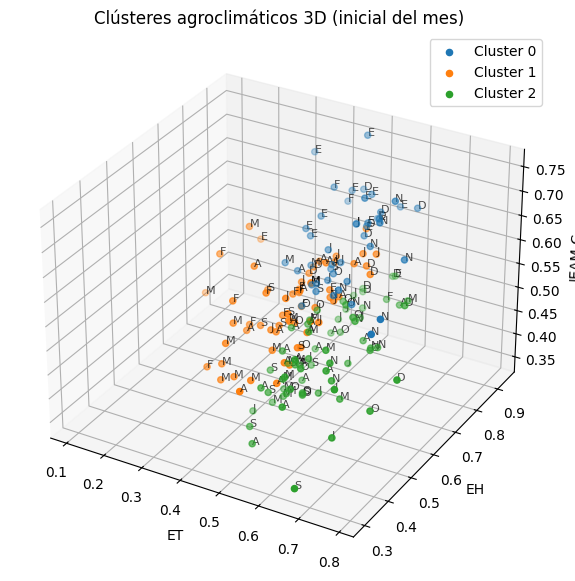

In [26]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

for c in sorted(df_final['Cluster_IEAM'].unique()):
    subset = df_final[df_final['Cluster_IEAM'] == c]
    ax.scatter(subset['ET'], subset['EH'], subset['IEAM_C'], label=f'Cluster {c}')

    # Etiquetas con inicial del mes
    for _, row in subset.iterrows():
        ax.text(
            row['ET'],
            row['EH'],
            row['IEAM_C'],
            row['Mes_inicial'],
            fontsize=8,
            alpha=0.7
        )

ax.set_xlabel("ET")
ax.set_ylabel("EH")
ax.set_zlabel("IEAM-C")
ax.set_title("Clústeres agroclimáticos 3D (inicial del mes)")
ax.legend()
plt.show()


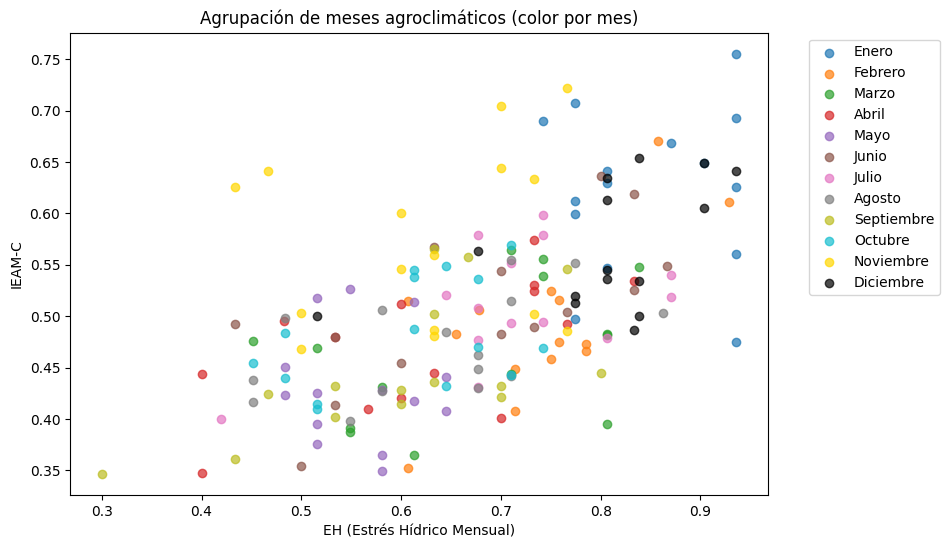

In [27]:
import matplotlib.pyplot as plt

# Orden de los meses
meses_orden = [
    'Enero','Febrero','Marzo','Abril','Mayo','Junio',
    'Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre'
]

# Colores por mes
colores = {
    'Enero':'tab:blue',
    'Febrero':'tab:orange',
    'Marzo':'tab:green',
    'Abril':'tab:red',
    'Mayo':'tab:purple',
    'Junio':'tab:brown',
    'Julio':'tab:pink',
    'Agosto':'tab:gray',
    'Septiembre':'tab:olive',
    'Octubre':'tab:cyan',
    'Noviembre':'gold',
    'Diciembre':'black'
}

plt.figure(figsize=(9,6))

for mes in meses_orden:
    subset = df_final[df_final['Mes_nombre'] == mes]
    if not subset.empty:
        plt.scatter(
            subset['EH'],
            subset['IEAM_C'],
            color=colores[mes],
            label=mes,
            alpha=0.7
        )

plt.xlabel("EH (Estrés Hídrico Mensual)")
plt.ylabel("IEAM-C")
plt.title("Agrupación de meses agroclimáticos (color por mes)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


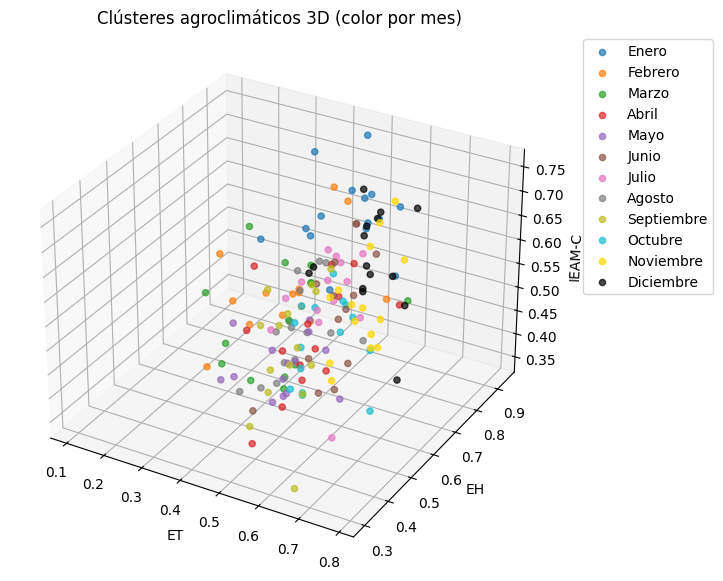

In [28]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

for mes in meses_orden:
    subset = df_final[df_final['Mes_nombre'] == mes]
    if not subset.empty:
        ax.scatter(
            subset['ET'],
            subset['EH'],
            subset['IEAM_C'],
            color=colores[mes],
            label=mes,
            alpha=0.7
        )

ax.set_xlabel("ET")
ax.set_ylabel("EH")
ax.set_zlabel("IEAM-C")
ax.set_title("Clústeres agroclimáticos 3D (color por mes)")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
